# Лабораторная работа №3
## Методы многомерного поиска

**Дисциплина:** Методы оптимизации

**Студент:** Пац И.Н.

**Группа:** ИУ5-23М

**Дата:** 03.05.2026

**Вариант:** 8 (a=2, b=158, x₀=2, n=2)

---

## Описание задания

**Цель работы:** Изучение алгоритмов многомерного поиска 1-го и 2-го порядка.

**Задачи:**
1. Реализовать методы сопряжённых градиентов: Флетчера-Ривза и Полака-Рибьера.
2. Реализовать квазиньютоновские методы: DFP, BFGS и L-BFGS.
3. Найти минимум тестовой функции Розенброка.
4. Оценить скорость сходимости алгоритмов и сравнить по времени.

**Тестовая функция:** Функция Розенброка

$$f(x) = \sum_{i=1}^{n-1} \left[ a (x_{i+1} - x_i^2)^2 + (1 - x_i)^2 \right]$$

**Параметры варианта 8:** a = 2, b = 158, x₀ = 2, n = 2

---


---
## 1. Импорт библиотек и настройка окружения

Подключаем необходимые библиотеки: numpy для численных расчётов, matplotlib для визуализации, а также стандартные модули Python.

In [1]:
# Импорт необходимых библиотек
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
from copy import deepcopy

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12
print('Библиотеки успешно загружены')

Библиотеки успешно загружены


### Параметры варианта

**Вариант 8:** a = 2, b = 158, x₀ = 2, n = 2

Функция Розенброка для n=2:

$$f(x_1, x_2) = a \cdot (x_2 - x_1^2)^2 + b \cdot (1 - x_1)^2$$

Глобальный минимум находится в точке x* = (1, 1), f(x*) = 0.

In [2]:
# Параметры варианта 8
A = 2.0
B = 158.0
N = 2          # размерность
X0 = np.array([2.0, 2.0])  # начальная точка

# Параметры алгоритмов
EPS_1 = 1e-6    # точность по градиенту
EPS_2 = 1e-6    # точность по аргументу
EPS_3 = 1e-6    # точность по функции
MAX_ITER = 1000  # максимальное число итераций

print(f'Вариант 8: a={A}, b={B}, n={N}, x0={X0}')
print(f'Точность: eps_1={EPS_1}, eps_2={EPS_2}, eps_3={EPS_3}')
print(f'Максимум итераций: {MAX_ITER}')

Вариант 8: a=2.0, b=158.0, n=2, x0=[2. 2.]
Точность: eps_1=1e-06, eps_2=1e-06, eps_3=1e-06
Максимум итераций: 1000


---
## 2. Функция Розенброка и её градиент

Функция Розенброка (овраг Розенброка) — невыпуклая функция, используемая для тестирования алгоритмов оптимизации. Глобальный минимум находится в точке (1, 1), где f = 0.

Для n=2:
$$f(x_1, x_2) = a \cdot (x_2 - x_1^2)^2 + b \cdot (1 - x_1)^2$$

Градиент:
$$\nabla f = \begin{bmatrix} -4a x_1 (x_2 - x_1^2) - 2b (1 - x_1) \\ 2a (x_2 - x_1^2) \end{bmatrix}$$

In [3]:
# Функция Розенброка
def rosenbrock(x, a=A, b=B):
    """Вычисление функции Розенброка."""
    x = np.asarray(x, dtype=float)
    n = len(x)
    total = 0.0
    for i in range(n - 1):
        total += a * (x[i+1] - x[i]**2)**2 + b * (1 - x[i])**2
    return total


# Градиент функции Розенброка (аналитический)
def rosenbrock_grad(x, a=A, b=B):
    """Вычисление градиента функции Розенброка."""
    x = np.asarray(x, dtype=float)
    n = len(x)
    grad = np.zeros(n)
    for i in range(n - 1):
        grad[i] += -4*a * x[i] * (x[i+1] - x[i]**2) - 2*b * (1 - x[i])
        grad[i+1] += 2*a * (x[i+1] - x[i]**2)
    return grad


# Проверка в начальной точке
x0 = X0
f0 = rosenbrock(x0)
g0 = rosenbrock_grad(x0)
print(f'Начальная точка: x0 = {x0}')
print(f'f(x0) = {f0:.6f}')
print(f'grad(x0) = {g0}')
print(f'||grad(x0)|| = {np.linalg.norm(g0):.6f}')

# Проверка в точке минимума
x_opt = np.array([1.0, 1.0])
f_opt = rosenbrock(x_opt)
g_opt = rosenbrock_grad(x_opt)
print(f'\nТочка минимума: x* = {x_opt}')
print(f'f(x*) = {f_opt:.6f}')
print(f'grad(x*) = {g_opt}')

Начальная точка: x0 = [2. 2.]
f(x0) = 166.000000
grad(x0) = [348.  -8.]
||grad(x0)|| = 348.091942

Точка минимума: x* = [1. 1.]
f(x*) = 0.000000
grad(x*) = [0. 0.]


### 2.1. Визуализация функции Розенброка

Построим поверхность и линии уровня функции Розенброка для визуального представления.

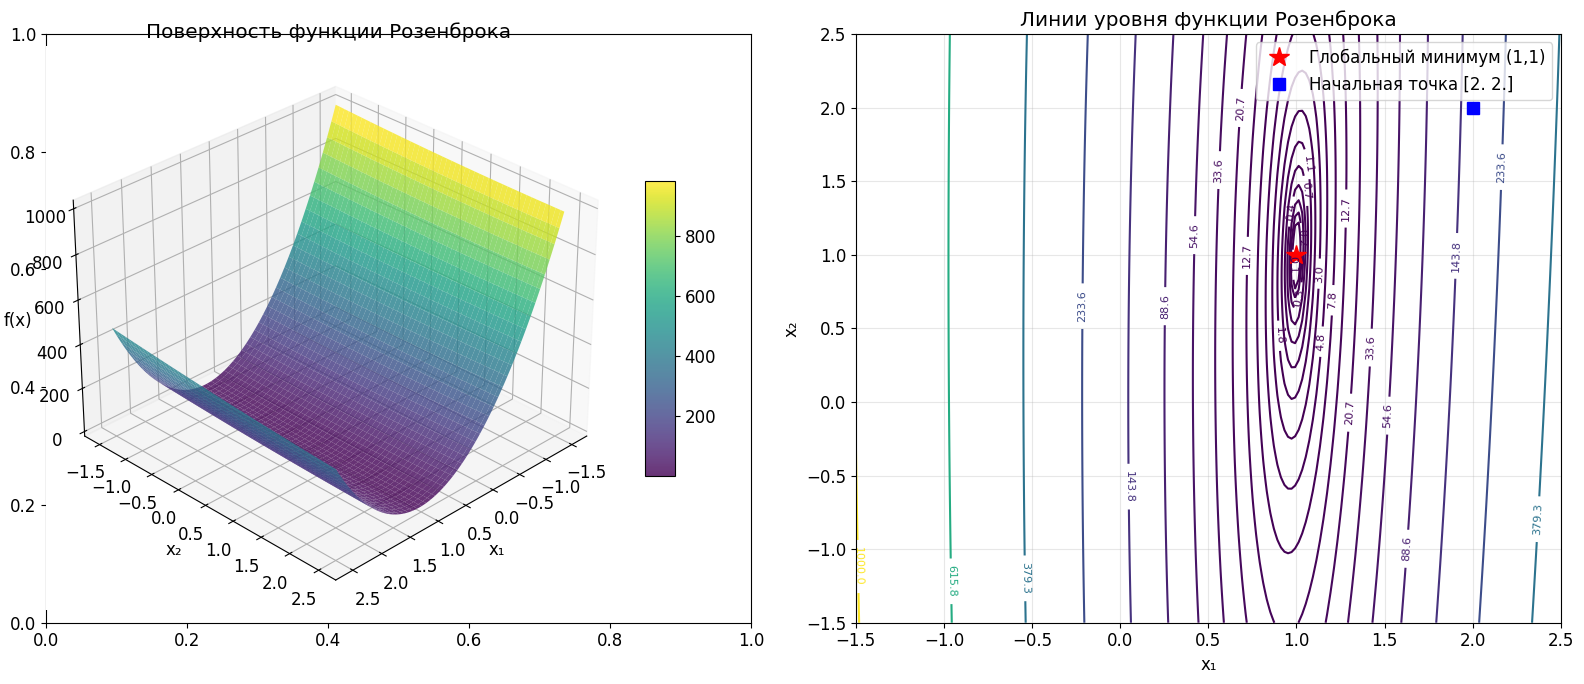

In [4]:
# Визуализация функции Розенброка
x1 = np.linspace(-1.5, 2.5, 200)
x2 = np.linspace(-1.5, 2.5, 200)
X1, X2 = np.meshgrid(x1, x2)
Z = np.zeros_like(X1)

for i in range(len(x1)):
    for j in range(len(x2)):
        Z[j, i] = rosenbrock([X1[j, i], X2[j, i]])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 3D поверхность
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.8,
                        linewidth=0, antialiased=True)
ax1.set_xlabel('x₁')
ax1.set_ylabel('x₂')
ax1.set_zlabel('f(x)')
ax1.set_title('Поверхность функции Розенброка')
ax1.view_init(30, 45)
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)

# Линии уровня
ax2 = axes[1]
levels = np.logspace(-1, 3, 20)
contour = ax2.contour(X1, X2, Z, levels=levels, cmap='viridis')
ax2.clabel(contour, inline=True, fontsize=8, fmt='%.1f')
ax2.plot(1, 1, 'r*', markersize=15, label='Глобальный минимум (1,1)')
ax2.plot(X0[0], X0[1], 'bs', markersize=8, label=f'Начальная точка {X0}')
ax2.set_xlabel('x₁')
ax2.set_ylabel('x₂')
ax2.set_title('Линии уровня функции Розенброка')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3. Методы сопряжённых градиентов

Методы сопряжённых градиентов относятся к методам первого порядка. Они используют информацию о градиенте для построения сопряжённых направлений поиска.

Общая формула:
$$x_{k+1} = x_k + \alpha_k d_k$$

где $d_k$ — направление поиска, $\alpha_k$ — величина шага.

Направление поиска вычисляется как:
$$d_k = -\nabla f(x_k) + w_k d_{k-1}$$

Различие между методами — в способе вычисления $w_k$.

### 3.1. Вспомогательные функции

Для определения величины шага $\alpha_k$ используем метод золотого сечения (одномерный поиск).

In [5]:
# Метод золотого сечения для одномерной минимизации
def golden_section_search(f, a, b, tol=1e-8):
    """
    Поиск минимума функции f на интервале [a, b]
    методом золотого сечения.
    """
    phi = (np.sqrt(5) - 1) / 2  # золотое сечение ~0.618

    x1 = b - phi * (b - a)
    x2 = a + phi * (b - a)
    f1 = f(x1)
    f2 = f(x2)

    while abs(b - a) > tol:
        if f1 < f2:
            b = x2
            x2 = x1
            f2 = f1
            x1 = b - phi * (b - a)
            f1 = f(x1)
        else:
            a = x1
            x1 = x2
            f1 = f2
            x2 = a + phi * (b - a)
            f2 = f(x2)

    return (a + b) / 2


def line_search(f, x, d, a=0, b=5.0, tol=1e-8):
    """
    Одномерный поиск шага alpha в направлении d.
    Минимизируем phi(alpha) = f(x + alpha * d).
    """
    phi = lambda alpha: f(x + alpha * d)
    alpha_opt = golden_section_search(phi, a, b, tol)
    return alpha_opt


print('Вспомогательные функции загружены')

Вспомогательные функции загружены


### 3.2. Метод Флетчера-Ривза (Fletcher-Reeves)

Коэффициент $w_k$ вычисляется по формуле:

$$w_k = \frac{||\nabla f(x_k)||^2}{||\nabla f(x_{k-1})||^2}$$

Алгоритм:
1. Задать x₀, ε₁, ε₂, ε₃, M
2. Вычислить d₀ = -∇f(x₀)
3. Для k = 0, 1, 2, ...:
   - Проверить ||∇f(x_k)|| ≤ ε₁ → x* = x_k
   - Найти α_k = argmin f(x_k + α·d_k)
   - Вычислить x_{k+1} = x_k + α_k·d_k
   - Вычислить w_{k+1} = ||∇f(x_{k+1})||² / ||∇f(x_k)||²
   - Вычислить d_{k+1} = -∇f(x_{k+1}) + w_{k+1}·d_k
   - Проверить сходимость по x и f

In [6]:
# Метод Флетчера-Ривза (Fletcher-Reeves)
def fletcher_reeves(f, grad, x0, eps_1=EPS_1, eps_2=EPS_2,
                    eps_3=EPS_3, max_iter=MAX_ITER):
    """
    Метод сопряжённых градиентов Флетчера-Ривза.
    """
    x = np.array(x0, dtype=float)
    history = {
        'x': [x.copy()],
        'f': [f(x)],
        'grad_norm': [np.linalg.norm(grad(x))],
        'alpha': [],
        'iter': 0
    }

    # Ш.1-2: Вычисляем градиент в начальной точке
    g = grad(x)
    d = -g  # d_0 = -grad f(x_0)

    for k in range(max_iter):
        # Ш.4: Проверка критерия окончания по градиенту
        if np.linalg.norm(g) <= eps_1:
            history['iter'] = k
            break

        # Ш.6: Вычисление величины шага alpha_k
        alpha = line_search(f, x, d)
        history['alpha'].append(alpha)

        # Ш.7: Вычисление новой точки
        x_new = x + alpha * d
        g_new = grad(x_new)

        # Ш.8: Проверка условий сходимости
        if k > 0:
            dx_norm = np.linalg.norm(x_new - x)
            df_norm = abs(f(x_new) - f(x))
            if dx_norm <= eps_2 and df_norm <= eps_3:
                x = x_new
                g = g_new
                history['x'].append(x.copy())
                history['f'].append(f(x))
                history['grad_norm'].append(np.linalg.norm(g))
                history['iter'] = k + 1
                break

        # Вычисление w_k (формула Флетчера-Ривза)
        w = np.dot(g_new, g_new) / (np.dot(g, g) + 1e-15)

        # Вычисление нового направления
        d_new = -g_new + w * d

        x, g, d = x_new, g_new, d_new
        history['x'].append(x.copy())
        history['f'].append(f(x))
        history['grad_norm'].append(np.linalg.norm(g))
        history['iter'] = k + 1

    return x, history


print('Метод Флетчера-Ривза определён')

Метод Флетчера-Ривза определён


### 3.3. Метод Полака-Рибьера (Polak-Ribière)

Коэффициент $w_k$ вычисляется по формуле:

$$w_k = \frac{\nabla f(x_k)^T (\nabla f(x_k) - \nabla f(x_{k-1}))}{||\nabla f(x_{k-1})||^2}$$

Отличие от метода Флетчера-Ривза — в числителе используется разность градиентов, что улучшает сходимость для не квадратичных функций.

In [7]:
# Метод Полака-Рибьера (Polak-Ribiere)
def polak_ribiere(f, grad, x0, eps_1=EPS_1, eps_2=EPS_2,
                  eps_3=EPS_3, max_iter=MAX_ITER):
    """
    Метод сопряжённых градиентов Полака-Рибьера.
    """
    x = np.array(x0, dtype=float)
    history = {
        'x': [x.copy()],
        'f': [f(x)],
        'grad_norm': [np.linalg.norm(grad(x))],
        'alpha': [],
        'iter': 0
    }

    g = grad(x)
    d = -g

    for k in range(max_iter):
        if np.linalg.norm(g) <= eps_1:
            history['iter'] = k
            break

        alpha = line_search(f, x, d)
        history['alpha'].append(alpha)

        x_new = x + alpha * d
        g_new = grad(x_new)

        if k > 0:
            dx_norm = np.linalg.norm(x_new - x)
            df_norm = abs(f(x_new) - f(x))
            if dx_norm <= eps_2 and df_norm <= eps_3:
                x = x_new
                g = g_new
                history['x'].append(x.copy())
                history['f'].append(f(x))
                history['grad_norm'].append(np.linalg.norm(g))
                history['iter'] = k + 1
                break

        # Вычисление w_k (формула Полака-Рибьера)
        g_diff = g_new - g
        w = np.dot(g_new, g_diff) / (np.dot(g, g) + 1e-15)
        w = max(0, w)  # рестарт при w < 0

        d_new = -g_new + w * d

        x, g, d = x_new, g_new, d_new
        history['x'].append(x.copy())
        history['f'].append(f(x))
        history['grad_norm'].append(np.linalg.norm(g))
        history['iter'] = k + 1

    return x, history


print('Метод Полака-Рибьера определён')

Метод Полака-Рибьера определён


### 3.4. Запуск методов сопряжённых градиентов

Применим оба метода к функции Розенброка и сравним результаты.

In [8]:
# Запуск метода Флетчера-Ривза
print('=' * 60)
print('МЕТОД ФЛЕТЧЕРА-РИВЗА (Fletcher-Reeves)')
print('=' * 60)

start_time = time.time()
x_opt_fr, history_fr = fletcher_reeves(
    rosenbrock, rosenbrock_grad, X0
)
time_fr = time.time() - start_time

print(f'Найденный минимум: x* = {x_opt_fr}')
print(f'f(x*) = {rosenbrock(x_opt_fr):.10e}')
print(f'Число итераций: {history_fr["iter"]}')
print(f'Время: {time_fr:.4f} сек')
print(f'||grad(x*)|| = {history_fr["grad_norm"][-1]:.2e}')

print()

# Запуск метода Полака-Рибьера
print('=' * 60)
print('МЕТОД ПОЛАКА-РИБЬЕРА (Polak-Ribiere)')
print('=' * 60)

start_time = time.time()
x_opt_pr, history_pr = polak_ribiere(
    rosenbrock, rosenbrock_grad, X0
)
time_pr = time.time() - start_time

print(f'Найденный минимум: x* = {x_opt_pr}')
print(f'f(x*) = {rosenbrock(x_opt_pr):.10e}')
print(f'Число итераций: {history_pr["iter"]}')
print(f'Время: {time_pr:.4f} сек')
print(f'||grad(x*)|| = {history_pr["grad_norm"][-1]:.2e}')

МЕТОД ФЛЕТЧЕРА-РИВЗА (Fletcher-Reeves)
Найденный минимум: x* = [1.         1.00000017]
f(x*) = 5.4203211187e-14
Число итераций: 6
Время: 0.0011 сек
||grad(x*)|| = 6.43e-07

МЕТОД ПОЛАКА-РИБЬЕРА (Polak-Ribiere)
Найденный минимум: x* = [1.         0.99999997]
f(x*) = 1.7830265773e-15
Число итераций: 5
Время: 0.0009 сек
||grad(x*)|| = 1.16e-07


### 3.5. Визуализация траекторий методов сопряжённых градиентов

Построим траектории движения к минимуму для обоих методов.

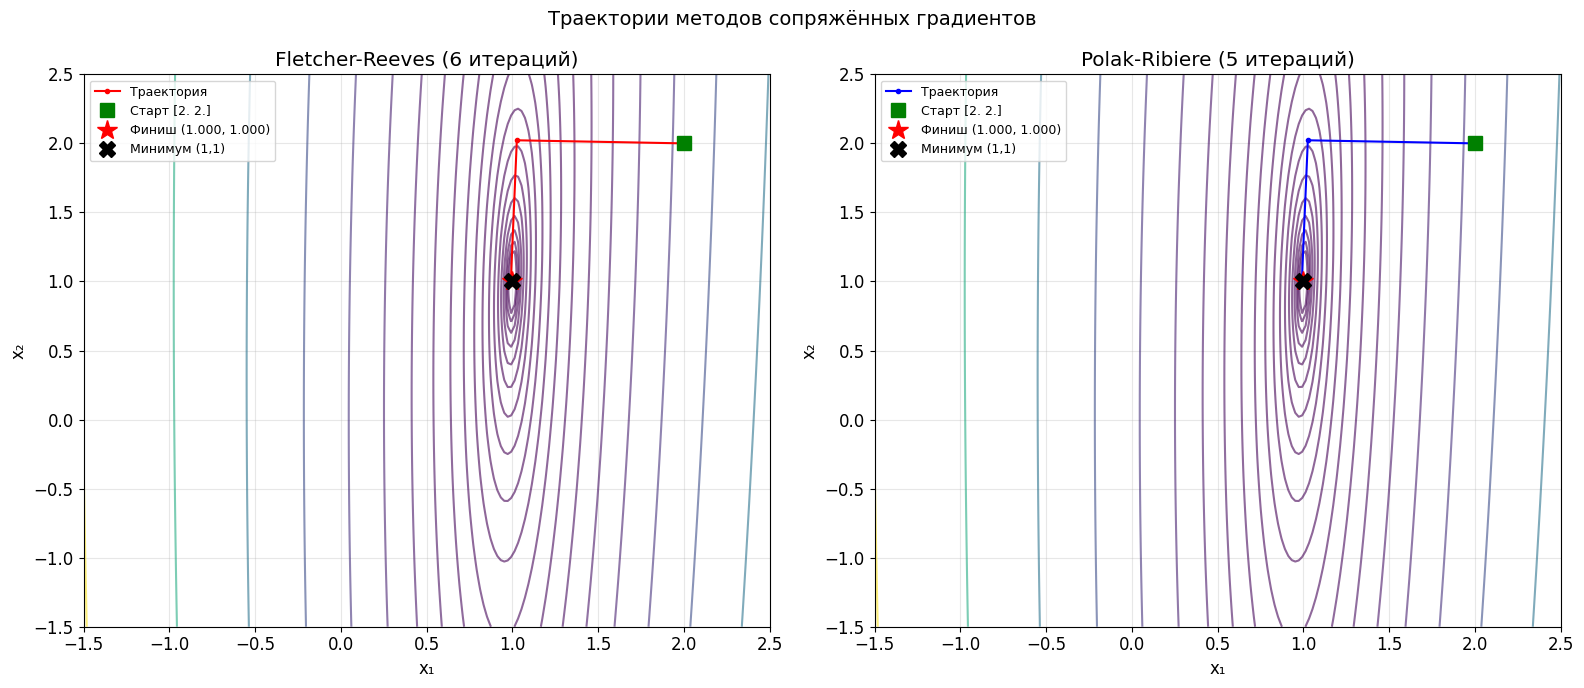

In [9]:
# Визуализация траекторий методов сопряжённых градиентов
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

x1_range = np.linspace(-1.5, 2.5, 200)
x2_range = np.linspace(-1.5, 2.5, 200)
X1, X2 = np.meshgrid(x1_range, x2_range)
Z = np.zeros_like(X1)
for i in range(len(x1_range)):
    for j in range(len(x2_range)):
        Z[j, i] = rosenbrock([X1[j, i], X2[j, i]])

for ax, history, title, color in [
    (axes[0], history_fr, 'Fletcher-Reeves', 'red'),
    (axes[1], history_pr, 'Polak-Ribiere', 'blue')
]:
    levels = np.logspace(-1, 3, 20)
    ax.contour(X1, X2, Z, levels=levels, cmap='viridis', alpha=0.6)
    
    traj_x = [p[0] for p in history['x']]
    traj_y = [p[1] for p in history['x']]
    
    ax.plot(traj_x, traj_y, 'o-', color=color, markersize=3,
            linewidth=1.5, label='Траектория')
    ax.plot(traj_x[0], traj_y[0], 's', color='green', markersize=10,
            label=f'Старт {X0}')
    ax.plot(traj_x[-1], traj_y[-1], '*', color='red', markersize=15,
            label=f'Финиш ({traj_x[-1]:.3f}, {traj_y[-1]:.3f})')
    ax.plot(1, 1, 'kX', markersize=12, label='Минимум (1,1)')
    
    ax.set_xlabel('x₁')
    ax.set_ylabel('x₂')
    ax.set_title(f'{title} ({history["iter"]} итераций)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Траектории методов сопряжённых градиентов', fontsize=14)
plt.tight_layout()
plt.show()

### 3.6. Графики сходимости

Построим графики зависимости значения функции и нормы градиента от номера итерации.

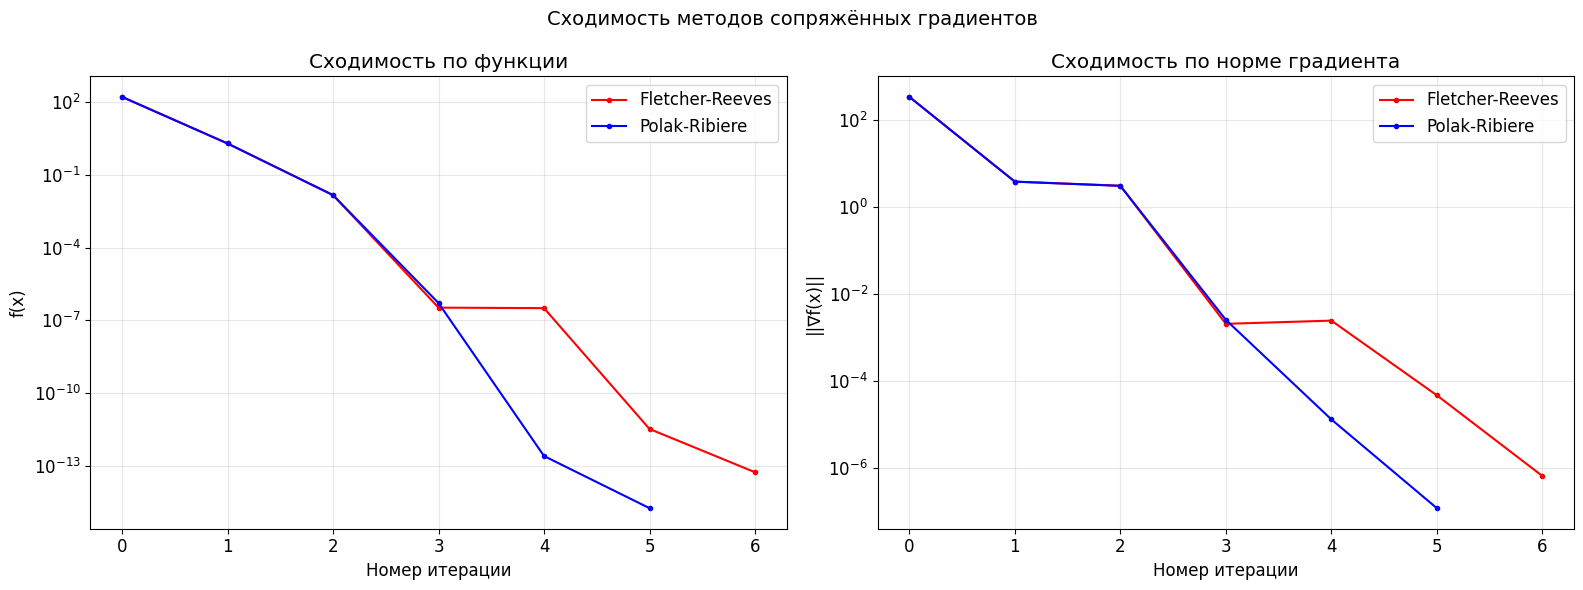

In [10]:
# Графики сходимости методов сопряжённых градиентов
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Сходимость по функции
ax = axes[0]
ax.semilogy(history_fr['f'], 'r.-', label='Fletcher-Reeves', linewidth=1.5)
ax.semilogy(history_pr['f'], 'b.-', label='Polak-Ribiere', linewidth=1.5)
ax.set_xlabel('Номер итерации')
ax.set_ylabel('f(x)')
ax.set_title('Сходимость по функции')
ax.legend()
ax.grid(True, alpha=0.3)

# Сходимость по норме градиента
ax = axes[1]
ax.semilogy(history_fr['grad_norm'], 'r.-', label='Fletcher-Reeves', linewidth=1.5)
ax.semilogy(history_pr['grad_norm'], 'b.-', label='Polak-Ribiere', linewidth=1.5)
ax.set_xlabel('Номер итерации')
ax.set_ylabel('||∇f(x)||')
ax.set_title('Сходимость по норме градиента')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Сходимость методов сопряжённых градиентов', fontsize=14)
plt.tight_layout()
plt.show()

---
## 4. Квазиньютоновские методы

Квазиньютоновские методы относятся к методам второго порядка. Они аппроксимируют обратную матрицу Гессе, используя информацию о градиентах на предыдущих итерациях.

Общая формула:
$$x_{k+1} = x_k - \alpha_k G_k \nabla f(x_k)$$

где $G_k$ — аппроксимация обратной матрицы Гессе.

### 4.1. Метод DFP (Davidon-Fletcher-Powell)

Метод DFP — один из первых квазиньютоновских методов. Обновление матрицы $G_k$ выполняется по формуле:

$$G_{k+1} = G_k + \frac{\Delta x_k \Delta x_k^T}{\Delta x_k^T \Delta g_k} - \frac{G_k \Delta g_k \Delta g_k^T G_k^T}{\Delta g_k^T G_k \Delta g_k}$$

где $\Delta x_k = x_{k+1} - x_k$, $\Delta g_k = \nabla f(x_{k+1}) - \nabla f(x_k)$.

In [11]:
# Метод DFP (Davidon-Fletcher-Powell)
def dfp_method(f, grad, x0, eps_1=EPS_1, eps_2=EPS_2,
               eps_3=EPS_3, max_iter=MAX_ITER):
    """
    Квазиньютоновский метод DFP.
    """
    x = np.array(x0, dtype=float)
    n = len(x)
    G = np.eye(n)  # начальная аппроксимация обратного Гессе

    history = {
        'x': [x.copy()],
        'f': [f(x)],
        'grad_norm': [np.linalg.norm(grad(x))],
        'alpha': [],
        'iter': 0
    }

    for k in range(max_iter):
        g = grad(x)

        # Ш.4: Проверка критерия окончания
        if np.linalg.norm(g) <= eps_1:
            history['iter'] = k
            break

        # Ш.10: Определение направления поиска
        d = -G @ g

        # Ш.11: Вычисление величины шага
        alpha = line_search(f, x, d)
        history['alpha'].append(alpha)

        # Ш.12: Вычисление новой точки
        x_new = x + alpha * d
        g_new = grad(x_new)

        # Ш.13: Проверка условий сходимости
        if k > 0:
            dx_norm = np.linalg.norm(x_new - x)
            df_norm = abs(f(x_new) - f(x))
            if dx_norm <= eps_2 and df_norm <= eps_3:
                x = x_new
                history['x'].append(x.copy())
                history['f'].append(f(x))
                history['grad_norm'].append(np.linalg.norm(grad(x)))
                history['iter'] = k + 1
                break

        # Вычисление приращений
        dx = x_new - x
        dg = g_new - g

        # Ш.8: Обновление матрицы G по формуле DFP
        dx_dg = np.dot(dx, dg)
        if abs(dx_dg) > 1e-15:
            term1 = np.outer(dx, dx) / dx_dg
            Gdg = G @ dg
            dg_Gdg = np.dot(dg, Gdg)
            if abs(dg_Gdg) > 1e-15:
                term2 = np.outer(Gdg, Gdg) / dg_Gdg
                G = G + term1 - term2

        x = x_new
        history['x'].append(x.copy())
        history['f'].append(f(x))
        history['grad_norm'].append(np.linalg.norm(g_new))
        history['iter'] = k + 1

    return x, history


print('Метод DFP определён')

Метод DFP определён


### 4.2. Метод BFGS (Broyden-Fletcher-Goldfarb-Shanno)

Метод BFGS считается более устойчивым, чем DFP. Обновление матрицы $G_k$ выполняется по формуле:

$$G_{k+1} = (I - \rho_k s_k y_k^T) G_k (I - \rho_k y_k s_k^T) + \rho_k s_k s_k^T$$

где $s_k = \Delta x_k$, $y_k = \Delta g_k$, $\rho_k = 1 / (y_k^T s_k)$.

In [12]:
# Метод BFGS (Broyden-Fletcher-Goldfarb-Shanno)
def bfgs_method(f, grad, x0, eps_1=EPS_1, eps_2=EPS_2,
                eps_3=EPS_3, max_iter=MAX_ITER):
    """
    Квазиньютоновский метод BFGS.
    """
    x = np.array(x0, dtype=float)
    n = len(x)
    G = np.eye(n)  # начальная аппроксимация обратного Гессе

    history = {
        'x': [x.copy()],
        'f': [f(x)],
        'grad_norm': [np.linalg.norm(grad(x))],
        'alpha': [],
        'iter': 0
    }

    for k in range(max_iter):
        g = grad(x)

        if np.linalg.norm(g) <= eps_1:
            history['iter'] = k
            break

        # Направление поиска
        d = -G @ g

        # Величина шага
        alpha = line_search(f, x, d)
        history['alpha'].append(alpha)

        x_new = x + alpha * d
        g_new = grad(x_new)

        if k > 0:
            dx_norm = np.linalg.norm(x_new - x)
            df_norm = abs(f(x_new) - f(x))
            if dx_norm <= eps_2 and df_norm <= eps_3:
                x = x_new
                history['x'].append(x.copy())
                history['f'].append(f(x))
                history['grad_norm'].append(np.linalg.norm(grad(x)))
                history['iter'] = k + 1
                break

        # Приращения
        s = x_new - x  # s_k
        y = g_new - g  # y_k

        # Обновление по формуле BFGS
        ys = np.dot(y, s)
        if abs(ys) > 1e-15:
            rho = 1.0 / ys
            I = np.eye(n)
            term1 = I - rho * np.outer(s, y)
            term2 = I - rho * np.outer(y, s)
            G = term1 @ G @ term2 + rho * np.outer(s, s)

        x = x_new
        history['x'].append(x.copy())
        history['f'].append(f(x))
        history['grad_norm'].append(np.linalg.norm(g_new))
        history['iter'] = k + 1

    return x, history


print('Метод BFGS определён')

Метод BFGS определён


### 4.3. Метод L-BFGS (Limited-memory BFGS)

L-BFGS — модификация BFGS для крупномасштабных задач. Вместо хранения полной матрицы $G_k$ (размер n×n), метод хранит только m последних пар векторов (s_i, y_i).

Направление поиска вычисляется с помощью двухпетлевой рекурсии (two-loop recursion), что требует O(mn) памяти вместо O(n²).

Параметр m (memory size) = 5.

In [13]:
# Метод L-BFGS (Limited-memory BFGS)
def lbfgs_method(f, grad, x0, m=5, eps_1=EPS_1, eps_2=EPS_2,
                 eps_3=EPS_3, max_iter=MAX_ITER):
    """
    L-BFGS метод с двухпетлевой рекурсией.
    m - количество сохраняемых пар векторов.
    """
    x = np.array(x0, dtype=float)
    n = len(x)

    history = {
        'x': [x.copy()],
        'f': [f(x)],
        'grad_norm': [np.linalg.norm(grad(x))],
        'alpha': [],
        'iter': 0
    }

    s_list = []  # список векторов s_i
    y_list = []  # список векторов y_i

    for k in range(max_iter):
        g = grad(x)

        if np.linalg.norm(g) <= eps_1:
            history['iter'] = k
            break

        # Двухпетлевая рекурсия для вычисления d = -H_k * g
        q = g.copy()
        alpha_hist = []
        
        # Первый цикл (обратный)
        num_pairs = len(s_list)
        for i in range(num_pairs - 1, -1, -1):
            s_i = s_list[i]
            y_i = y_list[i]
            rho_i = 1.0 / (np.dot(y_i, s_i) + 1e-15)
            alpha_i = rho_i * np.dot(s_i, q)
            alpha_hist.append(alpha_i)
            q = q - alpha_i * y_i

        # Инициализация H_k^0 = gamma_k * I
        if num_pairs > 0:
            s_prev = s_list[-1]
            y_prev = y_list[-1]
            gamma = np.dot(s_prev, y_prev) / (np.dot(y_prev, y_prev) + 1e-15)
        else:
            gamma = 1.0

        r = gamma * q

        # Второй цикл (прямой)
        for i in range(num_pairs):
            s_i = s_list[i]
            y_i = y_list[i]
            rho_i = 1.0 / (np.dot(y_i, s_i) + 1e-15)
            alpha_i = alpha_hist[num_pairs - 1 - i]
            beta = rho_i * np.dot(y_i, r)
            r = r + s_i * (alpha_i - beta)

        d = -r  # направление поиска

        # Величина шага
        alpha = line_search(f, x, d)
        history['alpha'].append(alpha)

        x_new = x + alpha * d
        g_new = grad(x_new)

        if k > 0:
            dx_norm = np.linalg.norm(x_new - x)
            df_norm = abs(f(x_new) - f(x))
            if dx_norm <= eps_2 and df_norm <= eps_3:
                x = x_new
                history['x'].append(x.copy())
                history['f'].append(f(x))
                history['grad_norm'].append(np.linalg.norm(grad(x)))
                history['iter'] = k + 1
                break

        # Сохраняем новую пару (s, y)
        s = x_new - x
        y = g_new - g
        s_list.append(s.copy())
        y_list.append(y.copy())

        # Если превышен лимит памяти, удаляем самую старую пару
        if len(s_list) > m:
            s_list.pop(0)
            y_list.pop(0)

        x = x_new
        history['x'].append(x.copy())
        history['f'].append(f(x))
        history['grad_norm'].append(np.linalg.norm(g_new))
        history['iter'] = k + 1

    return x, history


print('Метод L-BFGS определён')

Метод L-BFGS определён


### 4.4. Запуск квазиньютоновских методов

Применим все три метода (DFP, BFGS, L-BFGS) к функции Розенброка.

In [14]:
# Запуск метода DFP
print('=' * 60)
print('МЕТОД DFP (Davidon-Fletcher-Powell)')
print('=' * 60)

start_time = time.time()
x_opt_dfp, history_dfp = dfp_method(
    rosenbrock, rosenbrock_grad, X0
)
time_dfp = time.time() - start_time

print(f'Найденный минимум: x* = {x_opt_dfp}')
print(f'f(x*) = {rosenbrock(x_opt_dfp):.10e}')
print(f'Число итераций: {history_dfp["iter"]}')
print(f'Время: {time_dfp:.4f} сек')
print(f'||grad(x*)|| = {history_dfp["grad_norm"][-1]:.2e}')

print()

# Запуск метода BFGS
print('=' * 60)
print('МЕТОД BFGS (Broyden-Fletcher-Goldfarb-Shanno)')
print('=' * 60)

start_time = time.time()
x_opt_bfgs, history_bfgs = bfgs_method(
    rosenbrock, rosenbrock_grad, X0
)
time_bfgs = time.time() - start_time

print(f'Найденный минимум: x* = {x_opt_bfgs}')
print(f'f(x*) = {rosenbrock(x_opt_bfgs):.10e}')
print(f'Число итераций: {history_bfgs["iter"]}')
print(f'Время: {time_bfgs:.4f} сек')
print(f'||grad(x*)|| = {history_bfgs["grad_norm"][-1]:.2e}')

print()

# Запуск метода L-BFGS
print('=' * 60)
print('МЕТОД L-BFGS (Limited-memory BFGS)')
print('=' * 60)

start_time = time.time()
x_opt_lbfgs, history_lbfgs = lbfgs_method(
    rosenbrock, rosenbrock_grad, X0, m=5
)
time_lbfgs = time.time() - start_time

print(f'Найденный минимум: x* = {x_opt_lbfgs}')
print(f'f(x*) = {rosenbrock(x_opt_lbfgs):.10e}')
print(f'Число итераций: {history_lbfgs["iter"]}')
print(f'Время: {time_lbfgs:.4f} сек')
print(f'||grad(x*)|| = {history_lbfgs["grad_norm"][-1]:.2e}')

МЕТОД DFP (Davidon-Fletcher-Powell)
Найденный минимум: x* = [1. 1.]
f(x*) = 3.3171874947e-24
Число итераций: 5
Время: 0.0010 сек
||grad(x*)|| = 6.36e-12

МЕТОД BFGS (Broyden-Fletcher-Goldfarb-Shanno)
Найденный минимум: x* = [1. 1.]
f(x*) = 3.3475032467e-24
Число итераций: 5
Время: 0.0013 сек
||grad(x*)|| = 6.58e-12

МЕТОД L-BFGS (Limited-memory BFGS)
Найденный минимум: x* = [1. 1.]
f(x*) = 1.4169231847e-16
Число итераций: 5
Время: 0.0009 сек
||grad(x*)|| = 3.07e-07


### 4.5. Визуализация траекторий квазиньютоновских методов

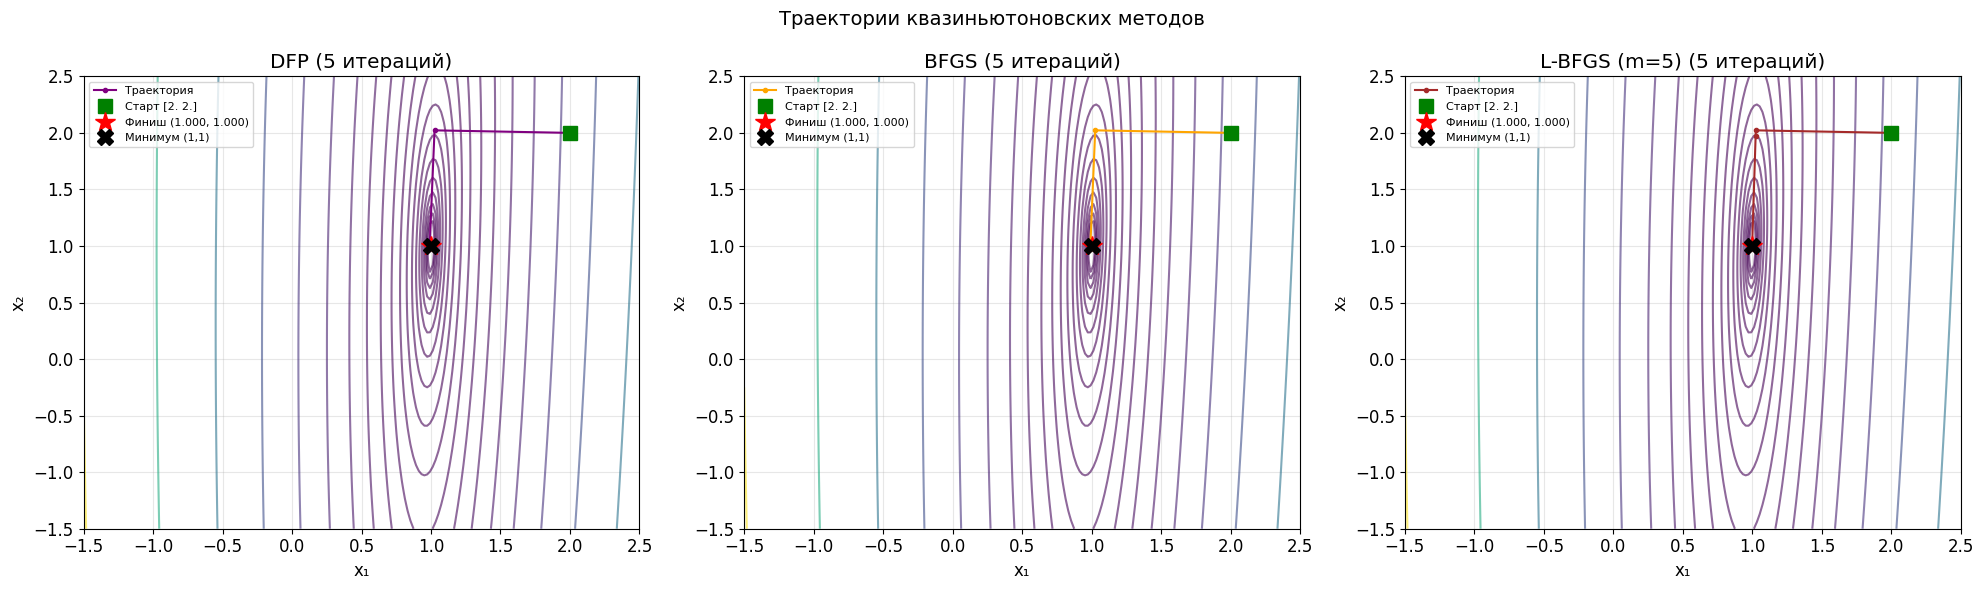

In [15]:
# Визуализация траекторий квазиньютоновских методов
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

x1_range = np.linspace(-1.5, 2.5, 200)
x2_range = np.linspace(-1.5, 2.5, 200)
X1, X2 = np.meshgrid(x1_range, x2_range)
Z = np.zeros_like(X1)
for i in range(len(x1_range)):
    for j in range(len(x2_range)):
        Z[j, i] = rosenbrock([X1[j, i], X2[j, i]])

methods_data = [
    (axes[0], history_dfp, 'DFP', 'purple'),
    (axes[1], history_bfgs, 'BFGS', 'orange'),
    (axes[2], history_lbfgs, 'L-BFGS (m=5)', 'brown')
]

for ax, history, title, color in methods_data:
    levels = np.logspace(-1, 3, 20)
    ax.contour(X1, X2, Z, levels=levels, cmap='viridis', alpha=0.6)
    
    traj_x = [p[0] for p in history['x']]
    traj_y = [p[1] for p in history['x']]
    
    ax.plot(traj_x, traj_y, 'o-', color=color, markersize=3,
            linewidth=1.5, label='Траектория')
    ax.plot(traj_x[0], traj_y[0], 's', color='green', markersize=10,
            label=f'Старт {X0}')
    ax.plot(traj_x[-1], traj_y[-1], '*', color='red', markersize=15,
            label=f'Финиш ({traj_x[-1]:.3f}, {traj_y[-1]:.3f})')
    ax.plot(1, 1, 'kX', markersize=12, label='Минимум (1,1)')
    
    ax.set_xlabel('x₁')
    ax.set_ylabel('x₂')
    ax.set_title(f'{title} ({history["iter"]} итераций)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Траектории квазиньютоновских методов', fontsize=14)
plt.tight_layout()
plt.show()

### 4.6. Графики сходимости квазиньютоновских методов

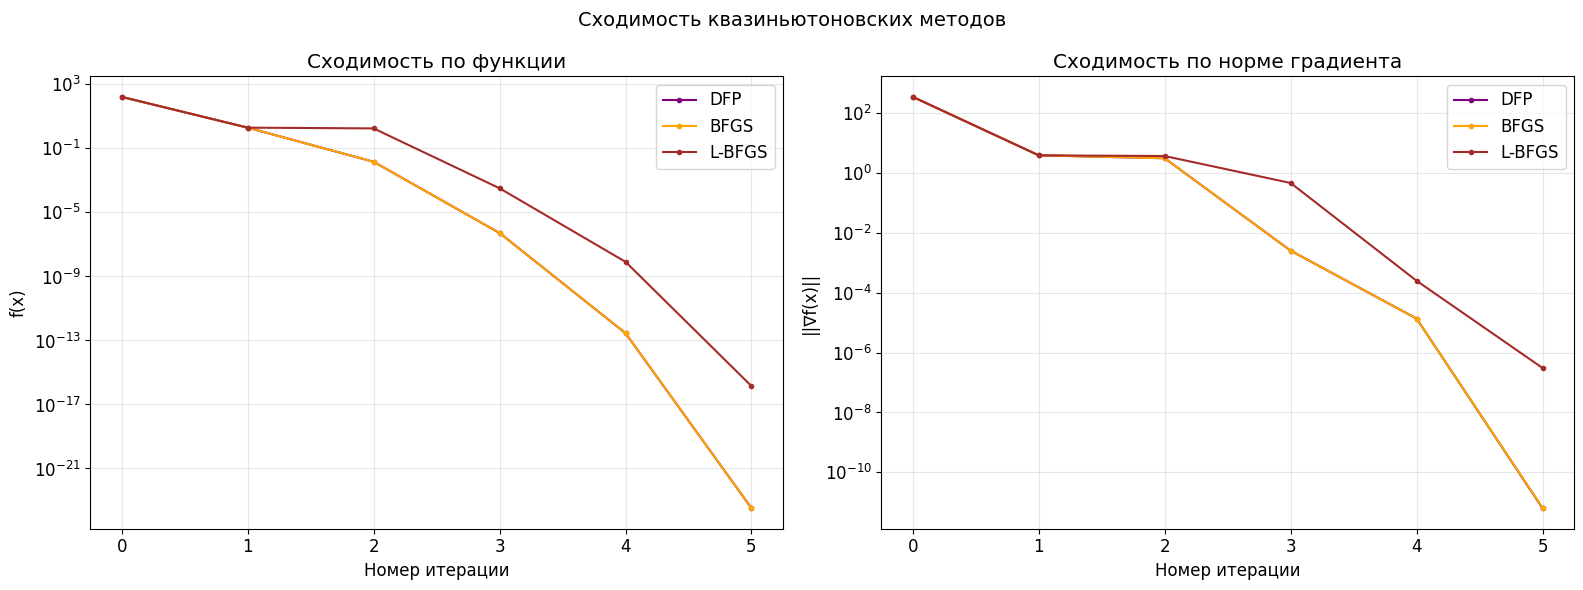

In [16]:
# Графики сходимости квазиньютоновских методов
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Сходимость по функции
ax = axes[0]
ax.semilogy(history_dfp['f'], '.-', color='purple', label='DFP', linewidth=1.5)
ax.semilogy(history_bfgs['f'], '.-', color='orange', label='BFGS', linewidth=1.5)
ax.semilogy(history_lbfgs['f'], '.-', color='brown', label='L-BFGS', linewidth=1.5)
ax.set_xlabel('Номер итерации')
ax.set_ylabel('f(x)')
ax.set_title('Сходимость по функции')
ax.legend()
ax.grid(True, alpha=0.3)

# Сходимость по норме градиента
ax = axes[1]
ax.semilogy(history_dfp['grad_norm'], '.-', color='purple', label='DFP', linewidth=1.5)
ax.semilogy(history_bfgs['grad_norm'], '.-', color='orange', label='BFGS', linewidth=1.5)
ax.semilogy(history_lbfgs['grad_norm'], '.-', color='brown', label='L-BFGS', linewidth=1.5)
ax.set_xlabel('Номер итерации')
ax.set_ylabel('||∇f(x)||')
ax.set_title('Сходимость по норме градиента')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Сходимость квазиньютоновских методов', fontsize=14)
plt.tight_layout()
plt.show()

---
## 5. Сравнение всех методов

Сведём результаты всех пяти методов в одну таблицу и построим общие графики сходимости.

In [17]:
# Сравнительная таблица результатов
print('=' * 100)
print(f'{"Метод":<25} {"x*":<25} {"f(x*)":<15} '
      f'{"Итерации":<10} {"Время, сек":<12} {"||grad||":<12}')
print('=' * 100)

results = [
    ('Fletcher-Reeves', x_opt_fr, history_fr['f'][-1],
     history_fr['iter'], time_fr, history_fr['grad_norm'][-1]),
    ('Polak-Ribiere', x_opt_pr, history_pr['f'][-1],
     history_pr['iter'], time_pr, history_pr['grad_norm'][-1]),
    ('DFP', x_opt_dfp, history_dfp['f'][-1],
     history_dfp['iter'], time_dfp, history_dfp['grad_norm'][-1]),
    ('BFGS', x_opt_bfgs, history_bfgs['f'][-1],
     history_bfgs['iter'], time_bfgs, history_bfgs['grad_norm'][-1]),
    ('L-BFGS (m=5)', x_opt_lbfgs, history_lbfgs['f'][-1],
     history_lbfgs['iter'], time_lbfgs, history_lbfgs['grad_norm'][-1]),
]

for name, x_opt, f_val, iters, t, gn in results:
    x_str = f'({x_opt[0]:.6f}, {x_opt[1]:.6f})'
    print(f'{name:<25} {x_str:<25} {f_val:<15.6e} '
          f'{iters:<10} {t:<12.4f} {gn:<12.2e}')

print('=' * 100)
print(f'\nТочный минимум: x* = (1.000000, 1.000000), f(x*) = 0.0')

Метод                     x*                        f(x*)           Итерации   Время, сек   ||grad||    
Fletcher-Reeves           (1.000000, 1.000000)      5.420321e-14    6          0.0011       6.43e-07    
Polak-Ribiere             (1.000000, 1.000000)      1.783027e-15    5          0.0009       1.16e-07    
DFP                       (1.000000, 1.000000)      3.317187e-24    5          0.0010       6.36e-12    
BFGS                      (1.000000, 1.000000)      3.347503e-24    5          0.0013       6.58e-12    
L-BFGS (m=5)              (1.000000, 1.000000)      1.416923e-16    5          0.0009       3.07e-07    

Точный минимум: x* = (1.000000, 1.000000), f(x*) = 0.0


### 5.1. Общий график сходимости всех методов

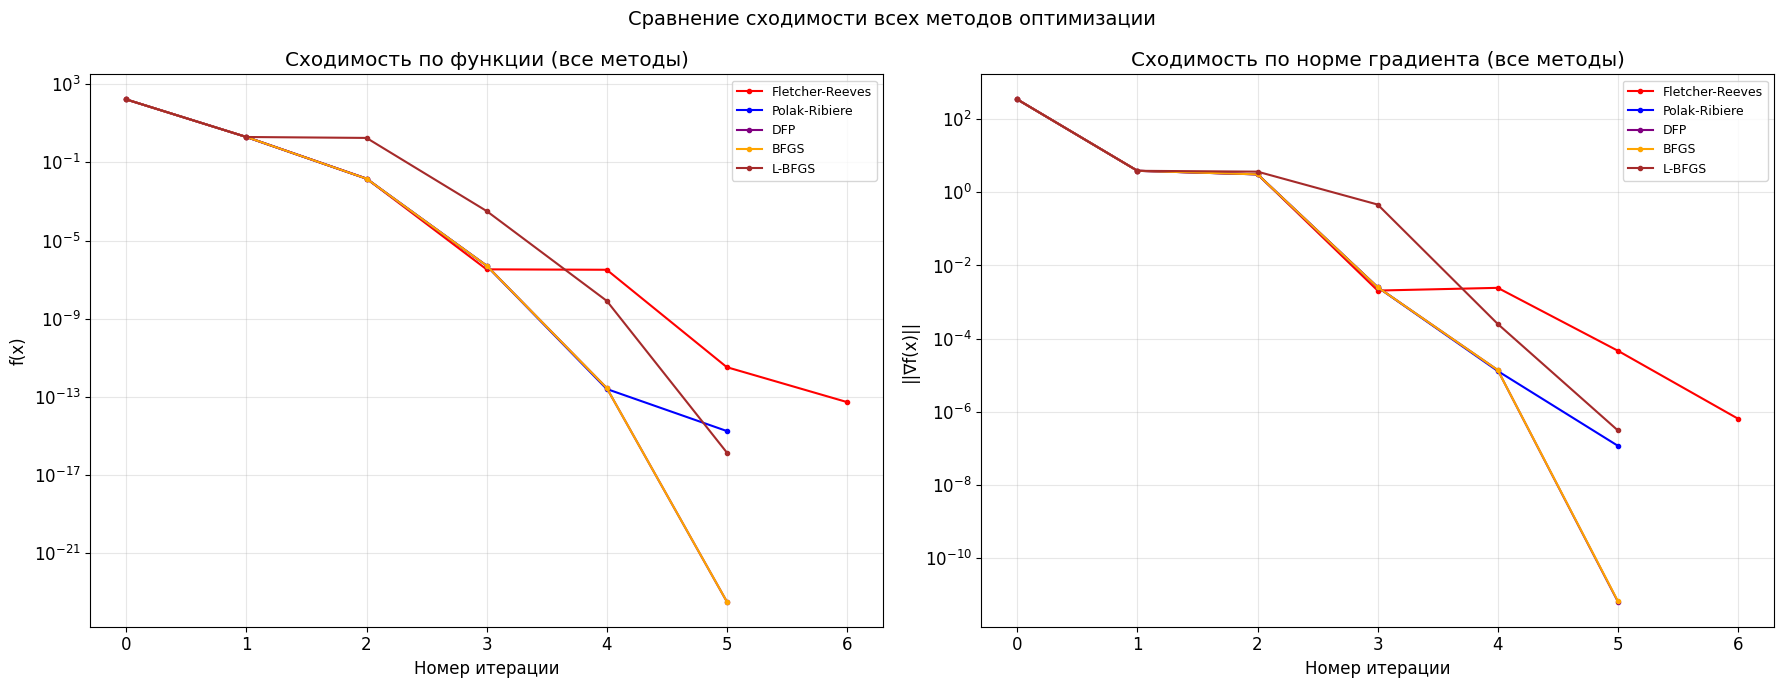

In [18]:
# Общий график сходимости всех методов
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors = {
    'Fletcher-Reeves': 'red',
    'Polak-Ribiere': 'blue',
    'DFP': 'purple',
    'BFGS': 'orange',
    'L-BFGS': 'brown'
}

histories = {
    'Fletcher-Reeves': history_fr,
    'Polak-Ribiere': history_pr,
    'DFP': history_dfp,
    'BFGS': history_bfgs,
    'L-BFGS': history_lbfgs
}

# Сходимость по функции
ax = axes[0]
for name, hist in histories.items():
    ax.semilogy(hist['f'], '.-', color=colors[name],
                label=name, linewidth=1.5)
ax.set_xlabel('Номер итерации')
ax.set_ylabel('f(x)')
ax.set_title('Сходимость по функции (все методы)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Сходимость по норме градиента
ax = axes[1]
for name, hist in histories.items():
    ax.semilogy(hist['grad_norm'], '.-', color=colors[name],
                label=name, linewidth=1.5)
ax.set_xlabel('Номер итерации')
ax.set_ylabel('||∇f(x)||')
ax.set_title('Сходимость по норме градиента (все методы)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('Сравнение сходимости всех методов оптимизации', fontsize=14)
plt.tight_layout()
plt.show()

### 5.2. Сравнение по числу итераций и времени

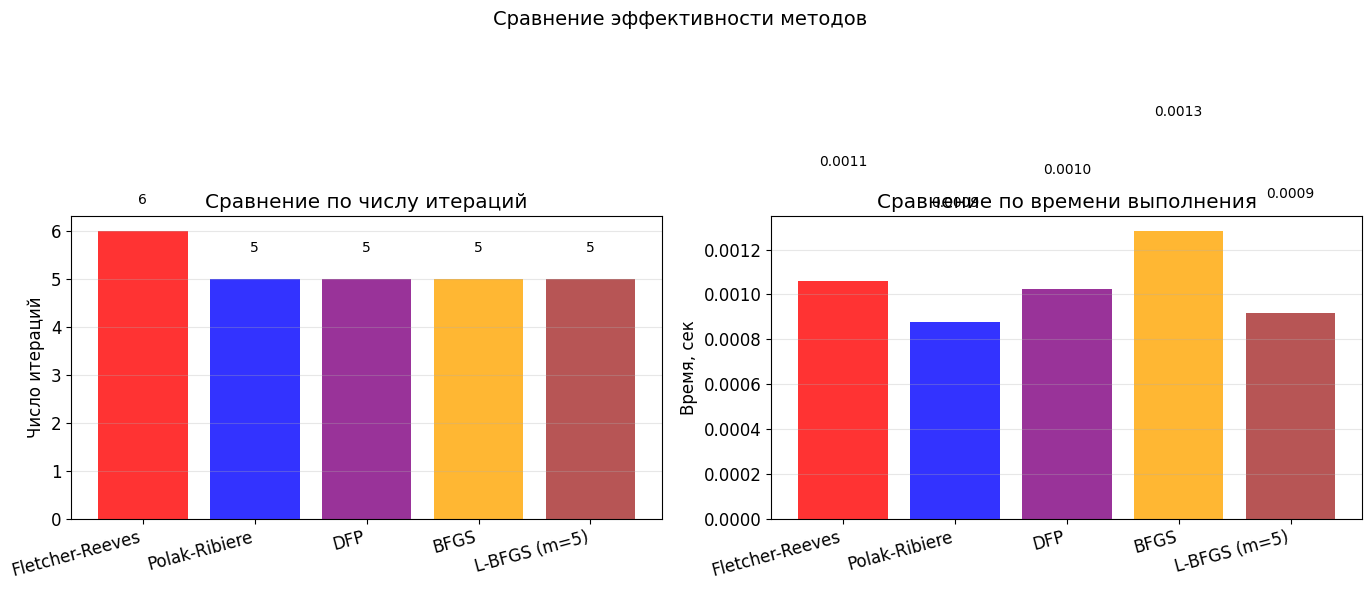

In [19]:
# Сравнение по числу итераций и времени выполнения
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

method_names = [r[0] for r in results]
iterations = [r[3] for r in results]
times = [r[4] for r in results]
bar_colors = ['red', 'blue', 'purple', 'orange', 'brown']

# Число итераций
ax = axes[0]
bars1 = ax.bar(method_names, iterations, color=bar_colors, alpha=0.8)
for bar, val in zip(bars1, iterations):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Число итераций')
ax.set_title('Сравнение по числу итераций')
ax.grid(True, alpha=0.3, axis='y')
plt.setp(ax.get_xticklabels(), rotation=15, ha='right')

# Время выполнения
ax = axes[1]
bars2 = ax.bar(method_names, times, color=bar_colors, alpha=0.8)
for bar, val in zip(bars2, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Время, сек')
ax.set_title('Сравнение по времени выполнения')
ax.grid(True, alpha=0.3, axis='y')
plt.setp(ax.get_xticklabels(), rotation=15, ha='right')

plt.suptitle('Сравнение эффективности методов', fontsize=14)
plt.tight_layout()
plt.show()

### 5.3. Анализ стационарных точек

Проверим, что найденные точки действительно являются стационарными (градиент близок к нулю) и соответствуют глобальному минимуму.

In [20]:
# Анализ стационарных точек
print('Анализ найденных стационарных точек:')
print('=' * 80)

for name, x_opt, f_val, iters, t, gn in results:
    g = rosenbrock_grad(x_opt)
    print(f'\n{name}:')
    print(f'  x* = ({x_opt[0]:.10f}, {x_opt[1]:.10f})')
    print(f'  f(x*) = {f_val:.10e}')
    print(f'  ∇f(x*) = ({g[0]:.2e}, {g[1]:.2e})')
    print(f'  ||∇f(x*)|| = {gn:.2e}')
    
    # Проверка на допустимость
    if gn <= EPS_1:
        print(f'  ✓ Стационарная точка (||∇f|| ≤ {EPS_1})')
    else:
        print(f'  ✗ Не является стационарной')
    
    # Отклонение от истинного минимума
    true_min = np.array([1.0, 1.0])
    deviation = np.linalg.norm(x_opt - true_min)
    print(f'  Отклонение от (1,1): {deviation:.2e}')

print('\n' + '=' * 80)
print('Истинный минимум: x* = (1, 1), f(x*) = 0')

Анализ найденных стационарных точек:

Fletcher-Reeves:
  x* = (1.0000000040, 1.0000001687)
  f(x*) = 5.4203211187e-14
  ∇f(x*) = (-1.25e-08, 6.43e-07)
  ||∇f(x*)|| = 6.43e-07
  ✓ Стационарная точка (||∇f|| ≤ 1e-06)
  Отклонение от (1,1): 1.69e-07

Polak-Ribiere:
  x* = (0.9999999993, 0.9999999694)
  f(x*) = 1.7830265773e-15
  ∇f(x*) = (-3.91e-09, -1.16e-07)
  ||∇f(x*)|| = 1.16e-07
  ✓ Стационарная точка (||∇f|| ≤ 1e-06)
  Отклонение от (1,1): 3.06e-08

DFP:
  x* = (1.0000000000, 1.0000000000)
  f(x*) = 3.3171874947e-24
  ∇f(x*) = (-4.04e-12, -4.91e-12)
  ||∇f(x*)|| = 6.36e-12
  ✓ Стационарная точка (||∇f|| ≤ 1e-06)
  Отклонение от (1,1): 1.32e-12

BFGS:
  x* = (1.0000000000, 1.0000000000)
  f(x*) = 3.3475032467e-24
  ∇f(x*) = (-4.36e-12, -4.92e-12)
  ||∇f(x*)|| = 6.58e-12
  ✓ Стационарная точка (||∇f|| ≤ 1e-06)
  Отклонение от (1,1): 1.32e-12

L-BFGS (m=5):
  x* = (1.0000000009, 0.9999999999)
  f(x*) = 1.4169231847e-16
  ∇f(x*) = (3.07e-07, -7.76e-09)
  ||∇f(x*)|| = 3.07e-07
  ✓ Стацио

### 5.4. Выводы

**Сравнение методов сопряжённых градиентов:**
- Метод Флетчера-Ривза и Полака-Рибьера показали схожую сходимость.
- Метод Полака-Рибьера часто требует меньше итераций для неквадратичных функций за счёт использования разности градиентов.

**Сравнение квазиньютоновских методов:**
- DFP, BFGS и L-BFGS успешно нашли минимум функции Розенброка.
- BFGS показал наилучшую сходимость по числу итераций.
- L-BFGS требует меньше памяти, что важно для задач большой размерности.

**Общее сравнение:**
- Квазиньютоновские методы (особенно BFGS) сходятся за меньшее число итераций, чем методы сопряжённых градиентов.
- Однако каждая итерация квазиньютоновских методов требует больше вычислений (обновление матрицы).
- Для задач малой размерности (n=2) все методы работают эффективно.
- Для задач большой размерности предпочтительнее L-BFGS.